# **Fichier d'analyse des résulats**

## Chargement librairies etc

In [112]:
import pandas as pd
import json

import matplotlib.pyplot as plt
from matplotlib import font_manager
import os


In [113]:
# Paramètres pour les graphiques
font_dir = "assets"

for file in os.listdir(font_dir):
    if file.endswith(".ttf"):
        font_manager.fontManager.addfont(os.path.join(font_dir, file))

plt.rcParams["font.family"] = "Marianne"
plt.rcParams.update({
    "font.family": "Marianne",

    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "regular",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
})

# Colors and styles for plotting
palette = {
    "Solar":      "#d66b0d",
    "Hydro":        "#2672b0",
    "Onshore":      "#72cbb7",
    "Offshore":     "#4d8377",
    "H2_CCG":       "#e4a701",
    "H2_TAC":       "#f0c040",
    "STEP_charge":  "#7a1616",
    "Fond":         "#ffffff",
    "STEP_discharge": "#ff0000",
    "Battery_charge": "#4B1063",
    "Battery_discharge": "#d126c9",
}

# Colonnes production (positives)
prod_cols = [
    'H2_CCG','H2_TAC','Hydro','Onshore','Offshore',
    'STEP_discharge','Battery_discharge','Solar'
]

# Colonnes charge
charge_cols = [
    'STEP_charge','Battery_charge'
]

In [114]:
df_global = pd.read_csv('results_annuel.csv', sep=';')
df_global.drop(columns=['t'], inplace=True)

print(df_global.columns)

parc = json.load(open('parc_annuel.json', 'r'))

Index(['Solar', 'Onshore', 'Offshore', 'Battery_stock', 'Battery_charge',
       'Battery_discharge', 'STEP_stock', 'STEP_charge', 'STEP_discharge',
       'H2_CCG', 'H2_TAC', 'Hydro', 'Load', 'Defailance', 'Exces'],
      dtype='object')


## **1. EOD : vue générale**

In [115]:
WEEK_TO_PLOT = 27

df= df_global.iloc[WEEK_TO_PLOT*7*24:(WEEK_TO_PLOT+1)*7*24]

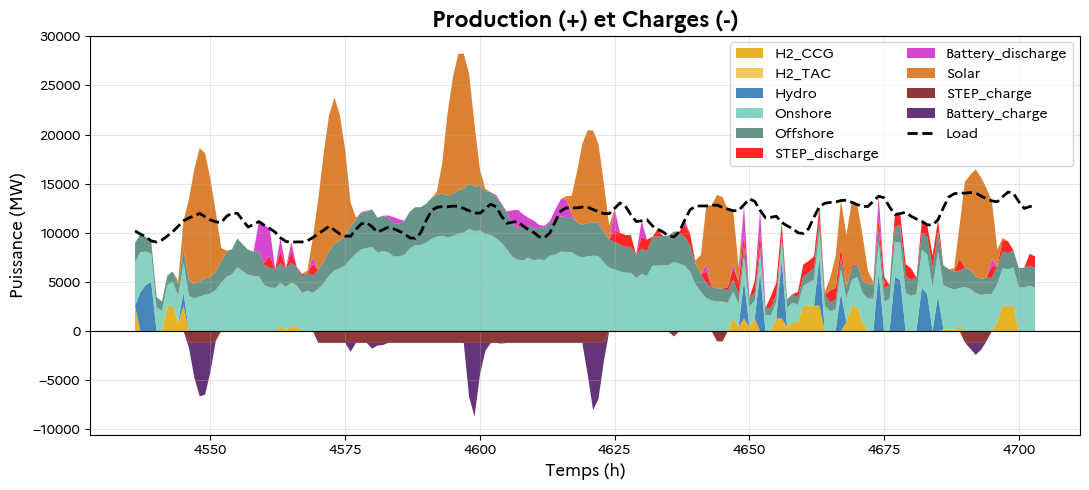

In [116]:
plt.figure(figsize=(11,5))

# --- STACK POSITIF ---
plt.stackplot(
    df.index,
    [df[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    labels=prod_cols,
    alpha=0.85
)

# --- STACK NEGATIF ---
plt.stackplot(
    df.index,
    [-df[c] for c in charge_cols],   # ⚠️ on met en négatif
    colors=[palette[c] for c in charge_cols],
    labels=charge_cols,
    alpha=0.85
)

# Ligne zéro
plt.axhline(0, color="black", linewidth=0.8)

# Load
plt.plot(df.index, df['Load'], color="black", linestyle='--', linewidth=2, label="Load")

plt.title("Production (+) et Charges (-)")
plt.xlabel("Temps (h)")
plt.ylabel("Puissance (MW)")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **2. Capacités installées**

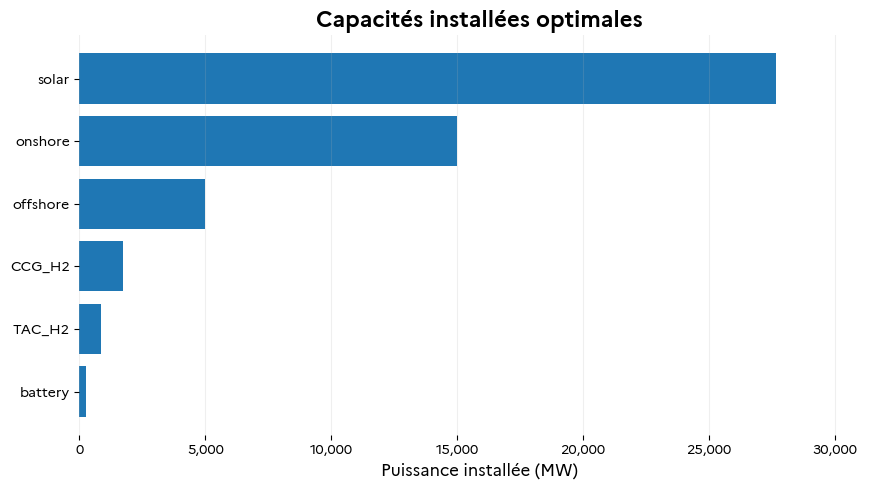

In [118]:
import json
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mtick
import os

# ------------------------
# Lecture du JSON
# ------------------------
with open("parc_resultats.json", "r") as f:
    parc = json.load(f)

data = parc["capacites_MW"].copy()

# ------------------------
# AJOUT H2 CCG + TAC
# ------------------------
if "H2" in parc:

    # ⚠️ adapte ces valeurs à ton modèle
    Pmax_CCG_unite = 430  # MW par unité CCG
    Pmax_TAC_unite = 85   # MW par unité TAC

    nb_CCG = parc["H2"]["CCG"]["nombre_installees"]
    nb_TAC = parc["H2"]["TAC"]["nombre_installees"]

    data["CCG_H2"] = nb_CCG * Pmax_CCG_unite
    data["TAC_H2"] = nb_TAC * Pmax_TAC_unite

# ------------------------
# Icônes associées
# ------------------------
icons = {
    "onshore": "assets/icons/eolien.png",
    "offshore": "assets/icons/eolien_offshore.png",
    "solar": "assets/icons/solaire.png",
    "battery": "assets/icons/batterie.png",
    "CCG_H2": "assets/icons/h2.png",
    "TAC_H2": "assets/icons/h2.png",
}

# ------------------------
# Fonction icône
# ------------------------
def add_icon(ax, x, y, icon_path, zoom=0.08):
    if not os.path.exists(icon_path):
        return
    img = plt.imread(icon_path)
    ab = AnnotationBbox(
        OffsetImage(img, zoom=zoom),
        (x, y),
        frameon=False,
        box_alignment=(0, 0.5)
    )
    ax.add_artist(ab)

# ------------------------
# Préparation données
# ------------------------
labels = list(data.keys())
values = list(data.values())



labels, values = zip(*sorted(zip(labels, values), key=lambda t: t[1]))

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(labels, values)

ax.set_title("Capacités installées optimales", fontweight="bold")
ax.set_xlabel("Puissance installée (MW)")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

# Icônes
xmin, xmax = ax.get_xlim()
icon_x = xmin + (xmax - xmin) * 0.02

for y, label in enumerate(labels):
    add_icon(ax, icon_x, y, icons.get(label, ""), zoom=0.07)

ax.margins(x=0.15)
ax.grid(axis="x", alpha=0.2)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## **3. Capacités de stockage**

/tmp/ipykernel_68071/1961083363.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Prod_totale"] = df["H2_CCG"] + df["H2_TAC"] + df["Hydro"] + df["Solar"] + df["Onshore"] + df["Offshore"]
/tmp/ipykernel_68071/1961083363.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ecret"] = df["Prod_totale"] - df["Load"]
/tmp/ipykernel_68071/1961083363.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



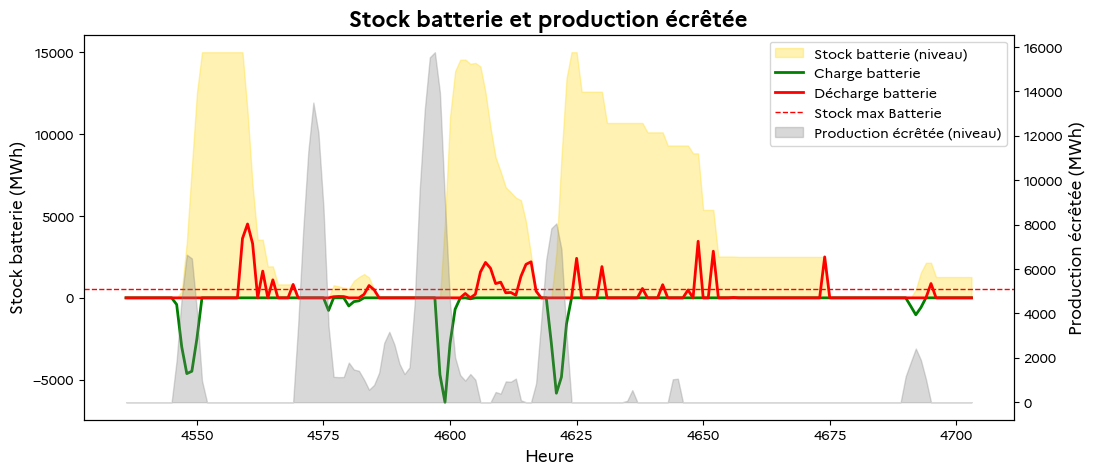

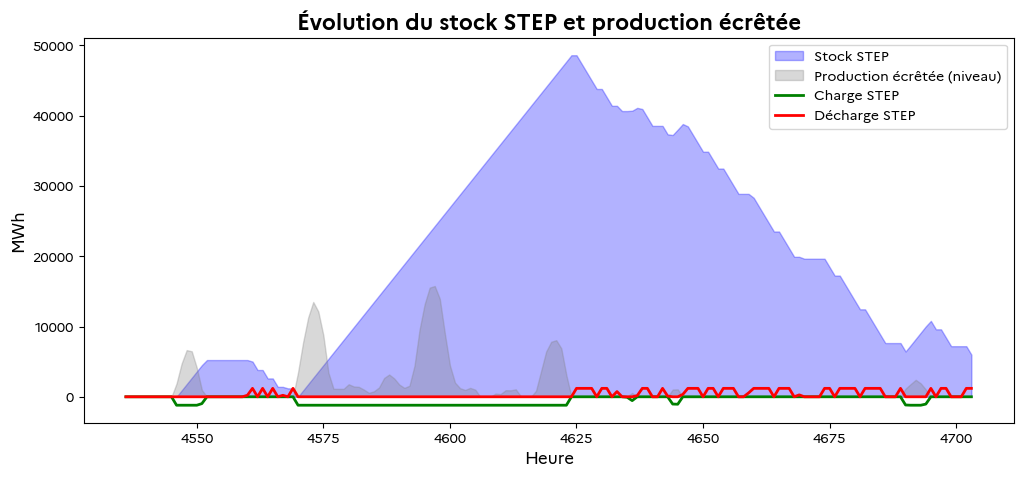

In [119]:
import numpy as np


# --- Lecture du JSON pour récupérer les capacités de stockage ---
with open("parc_resultats.json", "r") as f:
    parc = json.load(f)

CapaBattery = parc["capacites_MW"]["battery"]
d_battery = 2   # heures
stock_max_battery = CapaBattery * d_battery
rbattery = 0.85

# --- Calcul de la production totale ---
df["Prod_totale"] = df["H2_CCG"] + df["H2_TAC"] + df["Hydro"] + df["Solar"] + df["Onshore"] + df["Offshore"]

# --- Production écrêtée avant utilisation des stocks ---
df["Ecret"] = df["Prod_totale"] - df["Load"]
df["Ecret"] = df["Ecret"].clip(lower=0)  # pas de valeurs négatives

# --- Axe temps ---
time = df.index

# --- Plot Stock Batterie ---

fig, ax1 = plt.subplots(figsize=(12,5))

# Axe principal : stock batterie
ax1.fill_between(time, 0, df["Battery_stock"], color='gold', alpha=0.3, label="Stock batterie (niveau)")

ax1.plot(time, -df["Battery_charge"]*rbattery, linewidth=2, color='green', label="Charge batterie")
ax1.plot(time, df["Battery_discharge"]/rbattery, linewidth=2, color='red', label="Décharge batterie")
ax1.axhline(y=stock_max_battery, linestyle="--", linewidth=1, color="red", label="Stock max Batterie")
ax1.set_xlabel("Heure")
ax1.set_ylabel("Stock batterie (MWh)")


# Axe secondaire : production écrêtée
ax2 = ax1.twinx()
# ax2.plot(time, df["Ecret"], linestyle="--", linewidth=2,color="gray", label="Production écrêtée")
ax2.fill_between(time, 0, df["Ecret"], color='gray', alpha=0.3, label="Production écrêtée (niveau)")
ax2.set_ylabel("Production écrêtée (MWh)")

# Légende combinée
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Stock batterie et production écrêtée")
plt.show()

# --- Plot Stock STEP ---
# On peut calculer stock max STEP si on a Pmax_STEP et durée max 24*7h
#stock_max_STEP = ?

plt.figure(figsize=(12,5))
#plt.plot(time, df["STEP_stock"], linewidth=2, color='blue', label="Stock STEP")
plt.fill_between(time, 0, df["STEP_stock"], color='blue', alpha=0.3, label="Stock STEP")
#plt.axhline(y=stock_max_STEP, linestyle="--", color="red", label="Stock max STEP")
plt.fill_between(time, 0, df["Ecret"], color='gray', alpha=0.3, label="Production écrêtée (niveau)")
plt.plot(time, -df["STEP_charge"], linewidth=2, color='green', label = "Charge STEP")
plt.plot(time, df["STEP_discharge"], linewidth=2, color='red', label = "Décharge STEP")
plt.title("Évolution du stock STEP et production écrêtée")
plt.xlabel("Heure")
plt.ylabel("MWh")
plt.legend()
plt.show()



## **4. Hydraulique**

## **5. Centrales H2**